<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification & objects detection" -- Mai 20-21, 2026 - v1.1<br> 
CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<span style="color:Sienna; font-family:arial;font-size:1.2cm; font-weight:bold">
    Training & evaluation of a simple model<br> to classify the MNIST images
</span>    

<p style="color:Sienna; font-family:arial; font-size:15pt;">
    In this notebook we use a simple neural network model to classify the MNIST images to introduce :<br> 
    - the mains metrics used to <b>evaluate</b> a model trained to classify<br>
    - the <b>EarlyStopping</b> regularization to avoid the training overfit<br>
    - the <b>dropout</b> regularization to avoid the training overfit<br>
    - the <b>cross evaluation</b> approach to give a better evaluation of a trained model.
</p>    

# Preliminaries

## Import the Python modules

In [1]:
import os
# suppress tensorflow verbose warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys

# local module:
from utils.tools import elapsed_time_since, plot_loss_accuracy 

2026-05-17 15:26:00.637819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 15:26:00.650812: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-17 15:26:00.654361: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")

Python    : 3.12.12
tensorflow: 2.17.0 with keras 3.14.1
numpy     : 1.26.4


## Global settings

In [3]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

## Check wether GPU is available for tensorflow or not:

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"tensorflow running on {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
        # configure tensorflow to dynamically allocate GPU memory as needed:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("tensorflow running on CPU.")

tensorflow running on CPU.


2026-05-17 15:26:02.545278: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Create the `model` directory

In [5]:
print(f'{"WORKING DIRECTORY":17s}: {Path.cwd()}')

model_dir = Path("./model")
model_dir.mkdir(exist_ok=True)
print(f'{"MODEL DIRECTORY":17s}: {model_dir.absolute()}')

WORKING DIRECTORY: /home/jlc/work/IA-MachineLearning/18-DIADEM/DIADEM_DL/Classification/Notebooks
MODEL DIRECTORY  : /home/jlc/work/IA-MachineLearning/18-DIADEM/DIADEM_DL/Classification/Notebooks/model


# 1 - Prepare the MNIST dataset

## 1.1 Load the MNIST dataset (images and labels)

We use the keras `load_data` function to load the data from the MNIST 
(see [tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data)):<br>
- `train_img`, `train_lab` are the training images and labels,
- `valid_img`, `valid_lab` are the validation images and labels.

In [6]:
(train_img, train_lab), (valid_img, valid_lab) = keras.datasets.mnist.load_data()

Let's check the `shape` and `dtype` attributes of the numpy arrays:

In [7]:
print(f"train_img.shape: {train_img.shape}, dtype: {train_img.dtype}")
print(f"train_lab.shape: {train_lab.shape}, dtype: {train_lab.dtype}")
print(f"valid_img.shape: {valid_img.shape}, dtype: {valid_img.dtype}")
print(f"lab_vaild.shape: {valid_lab.shape}, dtype: {valid_lab.dtype}")

train_img.shape: (60000, 28, 28), dtype: uint8
train_lab.shape: (60000,), dtype: uint8
valid_img.shape: (10000, 28, 28), dtype: uint8
lab_vaild.shape: (10000,), dtype: uint8


## 1.2 Create the 3 datasets: `train`, `valid` & `test`

To follow the _state of the art_, we split the whole dataset into 3 datasets:
- **train dataset**: to train the model,
- **validation dataset**: to evaluate the model after each epoch of training,
- **test dataset**: to finaly evaluate the trained model.<br>

A simple way to do this is to keep the `train` dataset as is, and to split the current `valid` dataset in two equal subsets:
- a new smaller `valid` subset,
- a new `test` subset.<br>

We use the function [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) form the `sklearn` module:

In [8]:
from sklearn.model_selection import train_test_split
valid_img, test_img, valid_lab, test_lab = train_test_split(valid_img, valid_lab,
                                                            stratify=valid_lab,
                                                            test_size=0.5,
                                                            shuffle=True,
                                                            random_state=SEED)

Let's check the sizes of the 3 datasets:

In [9]:
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')
print(f'test :  {test_img.shape}')

train:  (60000, 28, 28)
valid:  (5000, 28, 28)
test :  (5000, 28, 28)


## 1.3 Check the quality of the dataset

Imbalanced classes can create some difficulties to train and evaluate the model: we verify that the proportion of digits remains homogenous in the 3 datasets thanks to the `plot_proportion_bar` function defined in the `utils.tools` module:

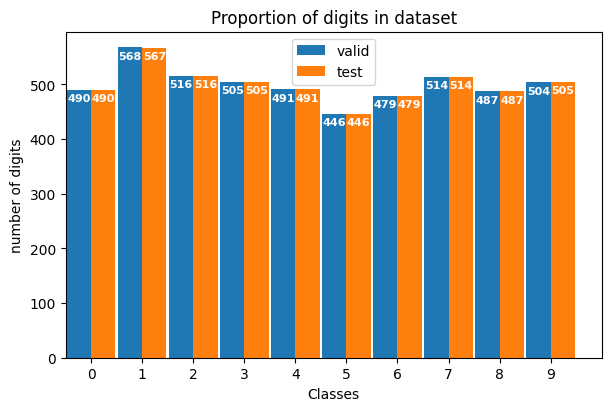

In [10]:
from utils.tools import plot_proportion_bar

# build the dictionnary of the classes proportion in each dataset:
prop = {}
prop['valid'] = [ (valid_lab == i).sum() for i in range(10)] # Comprehension list of # of 1, # of 2... in the vaild dataset
prop['test']  = [ (test_lab  == i).sum() for i in range(10)] # Comprehension list of # of 1, # of 2... in the test dataset
plot_proportion_bar(prop, range(10))

## 1.4 Define global parameters

To avoid hard-coding the number of train, valid and test images as well as the size of the images, these parameters are retrieved from the data set:
- with the shape attribute of the `train_img`, `valid_img` and `test_img` arrays
- with the size attribute of the first training image for example


In [11]:
NB_TRAIN_IMG = train_img.shape[0]  # number of training images
NB_VALID_IMG = valid_img.shape[0]  # number of validation images 
NB_TEST_IMG  = test_img.shape[0]   # number of test images
NB_PIXEL     = train_img[0].size   # number of elements (pixels) of the firts training image: 
NB_CLASS     = len(set(train_lab)) # number of classes:

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

60000 training images, 5000 validation images and 5000 test images
28x28=784 pixels in each image
10 classes found in the `train_lab` ndarray


# 2 - Process input data

Two treatments must be applied to the data from the MNIST database:
- **on images**: transform the matrices of  28$\,\times\,$28 pixels (`uint8`integers) into **normalized** vectors $(V_i)_{i=0..783}$ of 784 real values $V_i$ with $ 0 \leqslant V_i \leqslant 1$;
- **on labels**: transform scalar numbers into *one-hot* vectors.

## 2.1 - Transform input matrices into normalized vectors

We define the ndarrays `x_train`, `x_valid`, `x_test` by reshaping the ndarrays `train_img`, `valid_img`, `test_img`:

In [12]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255
x_test  = test_img.reshape(NB_TEST_IMG, NB_PIXEL)/255

#check:
print(f'train: {x_train.shape}, min: {x_train.min()}, max: {x_train.max()}')
print(f'valid: {x_valid.shape}, min: {x_valid.min()}, max: {x_valid.max()}')
print(f'test : {x_test.shape}, min: {x_test.min()}, max: {x_test.max()}')

train: (60000, 784), min: 0.0, max: 1.0
valid: (5000, 784), min: 0.0, max: 1.0
test : (5000, 784), min: 0.0, max: 1.0


## 2.2 - *one-hot* encoding of labels

We use the [to_categorical](https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical) function from **tf.keras.utils** module to define the *hot-one* encoded version of `train_lab`, `valid_lab` and `test_lab` arrays:

In [13]:
# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

# 3 - The Dense Neural Network (DNN)

 Now we will define a function to build a simple  **Dense Neural Network** to classify the MNIST images.<br>
 Of course, this is not the "state of the art" : convolutive NN, transformers have much more impressive scores to classify images,<br>
 but we just want want a simple model easy to understand with short training computation time.<br><br>
We will build this simple DNN:
- an **input layer** of 784 values (the pixel matrices of the 28 $\times$ 28 MNIST images flattened into vectors of 784 normalized `float` numbers),
- one **hidden layer** of 784 neurons using the `relu` activation function, with optional `dropout` regularization (will be used in section 6.2)
- an **output layer** of 10 neurons, for the classification of the 10 digits {0,1,2...9}, using the `softmax` activation function required for classifying.

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/simple-DNN.png" alt="simple-DNN.png" style="width:900px;"><br>
     [image: JLC]

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

def build_DNN(nb_input, nb_neuron, nb_class, dropout=0., seed=None, name=''):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential()
    model.add(Input(shape=(nb_input,), name='input'))                # INPUT layer
    model.add(Dropout(dropout, seed=seed))                           # drop out proportion: see section 6.2 
    model.add(Dense(nb_neuron, activation='relu', name='c1'))        # HIDDEN layer
    model.add(Dense(nb_class, activation='softmax', name='output'))  # OUTPUT layer
    
    model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
    
    if name: model.name = name
    return model

Lets's look at the number of _parameters_ (the _weights_) of the model:

In [15]:
NB_NEURON = NB_PIXEL

model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=SEED)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c1 (Dense)                      │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

# 4 - Reproducible training of the model

Epoch 1/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 6/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9934 - loss: 0.0191 - val_accuracy: 0.9776 - val_loss: 0.0968
Epoch 7/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9952 - loss: 0.0147 - val_accuracy: 0.9778 - val_loss: 0.1030
Epoch 8/12
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9957 - loss: 0.0126 - 

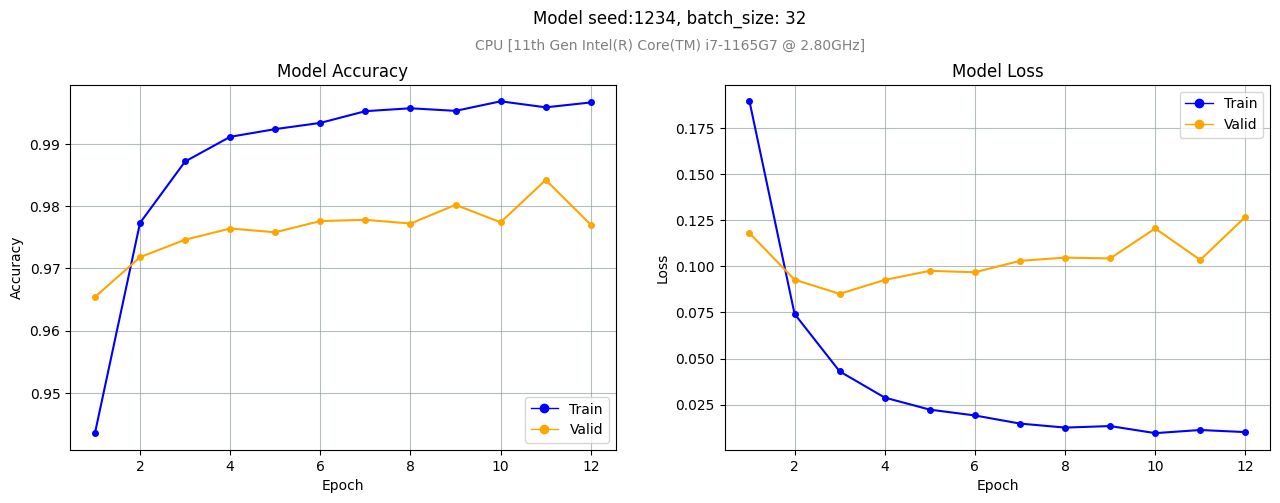

In [16]:
#
# 1 - Create the model with a fixed SEED:
#
SEED       = 1234
NB_NEURON  = NB_PIXEL
model_name = f'DNN_seed-{SEED}'
model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=SEED, name=model_name)

#
# 2 - Train the model:
#
NB_EPOCH   = 12
BATCH_SIZE = 32
hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=NB_EPOCH,       # the total number of successive trainings
                 batch_size=BATCH_SIZE) # fragmentation of the whole dada set in batches
#
# 3- Plot the accuracy & loss curves:
#
title = f'Model seed:{SEED}, batch_size: {BATCH_SIZE}'
plot_loss_accuracy(hist, message=title)

#
# 4 - Save the trained model
#
trained_name = f'{model_name}_epochs-{NB_EPOCH}_batchsize-{BATCH_SIZE}'
trained_file = f'{trained_name}_trained.keras'
trained_path = model_dir / trained_file
print(f'Saving trained model in <{trained_path}>')
model.save(trained_path)

We can observe on the `eval_loss` curve that the model starts to overfit when the evaluation loss begin to increase <span style="font-size:16pt;">🤔</span><br>
$\leadsto$ We will see in section 6 two techniques to avoid overfitting.

# 5 - Simple evaluation of the trained model

## 5.1 Load the structure and weights of a trained model:

We use the **scan_dir** function from the *utils.tolls* module to list the trained model files in the `model` directory:

In [50]:
help(scan_dir)

Help on function scan_dir in module utils.tools:

scan_dir(path, tag=None, sortbydate=False)
    To list the files in a directory tree, with optionnaly a tag to filter the names
    and a flag to sort files by date.



In [51]:
tree = scan_dir('model',          # directory to list
                tag='trained',    # file files with this tag
                sortbydate=True)  # sort by date

for i, f in enumerate(tree): print(f'[{i}]:', f)

[0]: model/DNN_seed-1234_epochs-12_batchsize-32_trained.keras
[1]: model/DNN_seed-1234_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras


Choose which trained model to load with the `input` Python primitive:

In [52]:
# ask to the user which model to load:
rank = int(input('rank of the model to load? ') )

rank of the model to load?  0


Load the choosen trained model file:

In [53]:
trained_file = tree[rank]
print(f'loading trained model from <{trained_file}>')
model = tf.keras.models.load_model(trained_file)

loading trained model from <model/DNN_seed-1234_epochs-12_batchsize-32_trained.keras>


## 5.1 Compute the predictions of the trained model using the **test dataset**

We can use the [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict) method of the model to get the labels predicted by the model with the test dataset: 

In [57]:
# Predicting labels (one-hot coded) for test images:
test_pred = model.predict(x_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Now we use the `np.argmax` function to transform the array of one-hot vectors `test_pred` into an array of integers:

In [58]:
pred_lab = np.argmax(test_pred, axis=-1)

Let's display the first 10 elements of the true test labels and predicted test labels:

In [61]:
print(pred_lab[:10])

# We use the context 'np.printoptions' to display floats with a fixed precision:
with np.printoptions(precision=2, suppress=True):
    print(test_pred[:10])

[0 8 0 1 3 8 5 1 2 4]
[[1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   1.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   1.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.94 0.06]
 [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  ]]


## 5.2 Model `accuracy`

`Accuracy` is a global metric quantifying the percentage of correct predictions a model makes relative to the total number of input items.

It is the most intuitive measure of performance answering the question "How often is the model right?" and is often used as first indicator before diving into more granular metrics. 

#### Direct calculation

In [62]:
nb_true_pred = (pred_lab == test_lab).sum()    # The number of true predictions on the test dataset
nb_test_lab  = len(test_lab)                   # The total number of labels in the test dataset
print(f'{nb_true_pred} true predictions over {nb_test_lab} test labels => accuracy = {100*nb_true_pred/nb_test_lab:.2f}%')

4885 true predictions over 5000 test labels => accuracy = 97.70%


#### Using the [evaluate](https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate) method of the model: 

In [63]:
# evaluate the model with the test dataset: 
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'accuracy = {test_acc*100:.2f}%')

157/157 - 0s - 2ms/step - accuracy: 0.9770 - loss: 0.1127
accuracy = 97.70%


## 5.4 Confusion matrix

<span style="color:Sienna; font-family:arial; font-size:12pt;">
The <b>Confusion Matrix</b> ($C$) for multiclass classification is a table which shows the predicted labels versus the actual labels.

We use the `show_conf_matrix` function of the local module **utils.tools** to encapsulate the [ConfusionMatrix.fromPredictions](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions) method from the **sklearn.metrics** module:


In [64]:
help(show_conf_matrix)

Help on function show_conf_matrix in module utils.tools:

show_conf_matrix(actual_label, predicted_label, class_label, figsize=(8, 7), cmap=<matplotlib.colors.LinearSegmentedColormap object at 0x7c23f68291c0>, ret=False)
    To display the confusion matrix.

    Parameters:
      actual_label:    the array of the actual labels (scalars)
      predicted_label: the array of the predicted labels (scalars)
      figsize:         the tuple(witdh, height) of the width and height of the figure
      cmap:            the desired color map (default=colormaps[name]['Blues'])
      ret:             whether to return the fig or not (useful for marimo)



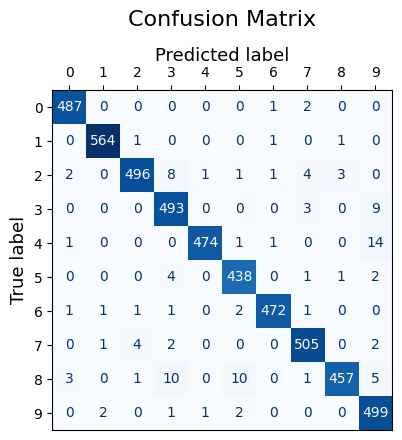

In [65]:
show_conf_matrix(test_lab, pred_lab, class_label=range(NB_CLASS), figsize=(6,5));

<span style="color:Sienna; font-family:arial; font-size:12pt;">
<ul>
  <li>The diagonal shows the <b>True Positives</b>: correctly predicted labels.<br>
      The number of <i>True Positives</i> $\mathrm{TP}$ for the class $k$ is: $\boxed{\mathrm{TP}(k) = C(k,k)}$  
  </li>
  <li>Off-diagonal cells show mis-classification:
      <ul>
        <li> a cell $C_{k,j}$ with $j \ne k$ on row $k$ is a <b>False Negative</b><br>
        The number of <i>False Negatives</i> for the class $k$ is: $\boxed{\mathrm{FN}(k) =  \sum_{j \ne k} C(k,j)}$ 
        <span style="font-size:11pt;">(sum of the cells on row $k$ excluding diagonal)</span><br>
        </li>
        <li> a cell $C_{i,k}$ with $i \ne k$ on the column $k$ is a <b>False Positive</b><br>
        The number of <i>False Positives</i> for the class $k$ is: $\boxed{\mathrm{FP}(k) = \sum_{i \ne k} C(i,k)}$
        <span style="font-size:11pt;">(sum of the cells on column $k$ excluding diagonal)</span><br>
        </li>
    </li>
</ul>
    

## 5.3 The classification metrics: Precision, Recall...

<span style="color:Sienna; font-family:arial; font-size:12pt;">
<b>Precision</b>($k$) = $\displaystyle{\frac{\mathrm{TP}(k)}{\mathrm{TP}(k) + \mathrm{FP}(k)}}$ : measures the quality of positive predictions.<br><br>
    - Answers the question “When the model predicts class X, how often is it right?”<br>
    - When does Precision matter most? When a False Positive is costly.
<br><br>
    
<b>Recall</b>($k$) = $\displaystyle{\frac{\mathrm{TP}(k)}{\mathrm{TP}(k) + \mathrm{FN}(k)}}$: measures the ability of the classifier to find all the positive samples.<br><br>
    - Answers the question “Of all true class X samples, how many did the model find?”<br>
    - High Recall $\leadsto$ the model is exhaustive, it tries not to miss anything.<br>
    - When does Recall matter most? When a False Negative is costly.<br><br> 

<b>F1-score</b>($k$) = 
$\displaystyle{2 \frac{\mathrm{Precision}(k) \times \mathrm{Recall}(k)}{\mathrm{Precision}(k) + \mathrm{Recall}(k)}}$<br>
    - F1-score is the harmonic mean of Precision and Recall.<br>
    - When to use F1: When working with unbalanced data and want a single number to compare different models, without ignoring either type of error.
</span>

We use the [classification_repport](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) function from the **scikit-learn.metrics$$ module to compute & print the metrics `precision`, `recall`... for each of the 10 classes:

In [66]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(test_lab, pred_lab))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       490
           1       0.99      0.99      0.99       567
           2       0.99      0.96      0.97       516
           3       0.95      0.98      0.96       505
           4       1.00      0.97      0.98       491
           5       0.96      0.98      0.97       446
           6       0.99      0.99      0.99       479
           7       0.98      0.98      0.98       514
           8       0.99      0.94      0.96       487
           9       0.94      0.99      0.96       505

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



The `support` is the number of occurrences of each class in the test dadaset.<br>
$\leadsto$ it is a useful information to check whether the dataset is balanced or not.

# 6 - Model regularization to avoid overfit

Overfitting occurs when the model is trained too well on the training data but poorly performs on new unseen data.<br>
That kind of model tries to memorize the training data and fails to generalize on new unseen data.


## 6.1 - Regularization with **EarlyStop** of the training

The [EralyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) callback of the **tf.keras** module offers a ùecanism to automatically stop learning by monitoring the growth of `val_accuracy` or the decrease of `val_loss` from one epoch to another.

We can thus define a list of callback functions that we pass as an argument to the `fit` method with the agument named _callbacks_:

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
Saving trained model in <model/DNN_seed-1234_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras>


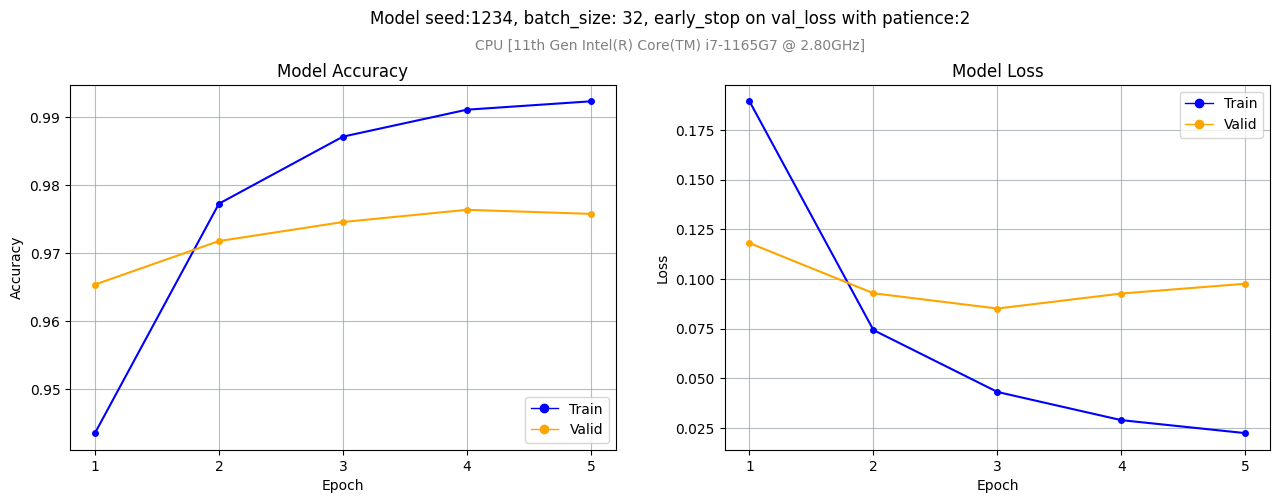

In [67]:
from tensorflow.keras.callbacks import EarlyStopping

#
# 1 - Create the model:
#
SEED       = 1234
NB_NEURON  = NB_PIXEL
model_name = f'DNN_seed-{SEED}'
model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=SEED, name=model_name)

#
# 2 - Define the 'callback' EarlyStopping in the callback list:
#
METRIC   = 'val_loss'
PATIENCE = 2
callbacks_list = [
    EarlyStopping(monitor=METRIC,      # The parameter to monitor
                  patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                  restore_best_weights=True,
                  verbose=1)
]
#
# 3 - Train the model:
#
NB_EPOCH   = 25  # the max number of epochs...
BATCH_SIZE = 32
hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=NB_EPOCH,      # the total number of successive trainings
                 batch_size=BATCH_SIZE, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)
#
# 4- Plot the accuracy & loss curves:
#
title = f'Model seed:{SEED}, batch_size: {BATCH_SIZE}, early_stop on {METRIC} with patience:{PATIENCE}'
plot_loss_accuracy(hist, message=title)

#
# 5 - Save the trained model
#
trained_name = f'{model_name}_epochs-{NB_EPOCH}_batchsize-{BATCH_SIZE}__earlystop-{METRIC}-{PATIENCE}'
trained_file = f'{trained_name}_trained.keras'
trained_path = model_dir / trained_file
print(f'Saving trained model in <{trained_path}>')
model.save(trained_path)

<span style="color:Blue; font-family:arial; font-size:11pt;">
    In the cell bellow you can copy/paste/modify previous cells:<br>
    - to load the trained model file choosen by its rank in the <i>scan_dir</i> output,<br>
    - to evaluate its accuracy & loss with the test dataset,<br>
    - to show its confusion matrix<br>
    - and print the "classification repport".
</span>

[0]: model/DNN_seed-1234_epochs-12_batchsize-32_trained.keras
[1]: model/DNN_seed-1234_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras
[2]: model/DNN_seed-1234_drop-0.4_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras
[3]: model/DNN_seed-1234_drop-0.3_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras
[4]: model/DNN_seed-1234_drop-0.5_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras



rank of the model to load?  2


loading trained model from <model/DNN_seed-1234_drop-0.4_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras>
test_accuracy = 98.44%, test_loss = 5.09e-02
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       490
           1       0.99      1.00      0.99       567
           2       0.99      0.98      0.99       516
           3       0.98      0.99      0.99       505
           4       0.99      0.97      0.98       491
           5       0.99      0.99      0.99       446
           6       1.00      0.99      0.99       479
           7       0.98      0.98      0.98       514
           8       0.98      0.98      0.98       487
           9       0.96      0.98      0.97       505

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



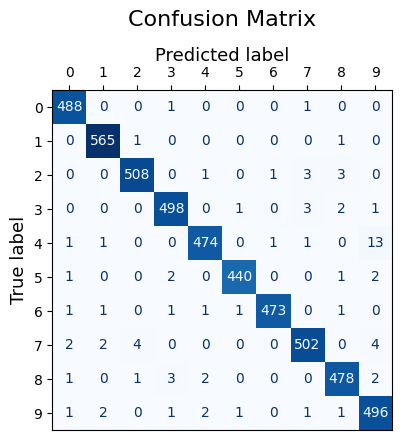

In [76]:
tree = scan_dir('model',          # directory to list
                tag='trained',    # file files with this tag
                sortbydate=True)  # sort by date

for i, f in enumerate(tree): print(f'[{i}]:', f)
    
# ask to the user which model to load:
rank = int(input('\nrank of the model to load? ') )

# Load the choosen model:
trained_file = tree[rank]
print(f'loading trained model from <{trained_file}>')
model = tf.keras.models.load_model(trained_file)

# evaluate the model with the test dataset: 
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'test_accuracy = {test_acc*100:.2f}%, test_loss = {test_loss:.2e}')

# Predicting labels for test images:
test_pred = model.predict(x_test, verbose=0)   # array of none-hot vectors
pred_lab  = np.argmax(test_pred, axis=-1)      # array of lavels (integers)

# Show the classification repport:
print("Classification Report:\n", classification_report(test_lab, pred_lab))

# Show confusion Matrix:
show_conf_matrix(test_lab, pred_lab, class_label=range(NB_CLASS), figsize=(6,5))

## 6.2 - Regularization with the **dropout** of neurons 

Another regularization technique to ovoid overfit is know as `dropout`: during training, dropout randomly “turns off” (drops) some neurons in a neural network.<br>
We can use the `dropout` argument of the `build_NN` function previously defined to build the network wit the dropout activated during training.

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9126 - loss: 0.2834 - val_accuracy: 0.9624 - val_loss: 0.1215
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9558 - loss: 0.1404 - val_accuracy: 0.9732 - val_loss: 0.0850
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9641 - loss: 0.1117 - val_accuracy: 0.9744 - val_loss: 0.0790
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9697 - loss: 0.0929 - val_accuracy: 0.9788 - val_loss: 0.0665
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9737 - loss: 0.0812 - val_accuracy: 0.9804 - val_loss: 0.0632
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9754 - loss: 0.0743 - val_accuracy: 0.9806 - val_loss: 0.0634
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9772 - loss: 0.0694 - val_accuracy: 0.9820 - val_loss: 0.0588
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9790 - loss: 0.0639 - 

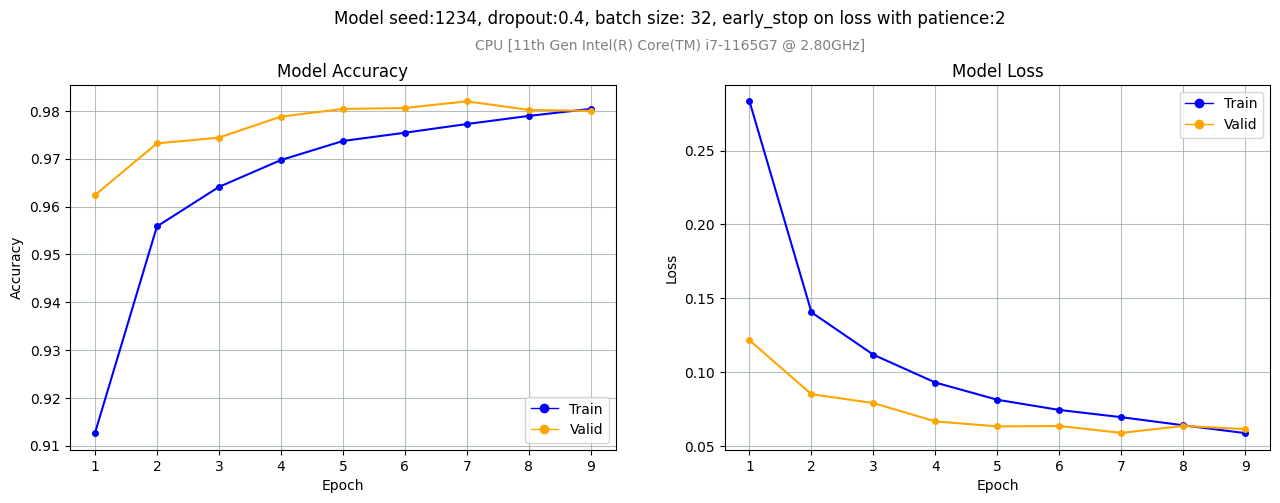

In [69]:
#
# 1 - Create the model :
#
SEED       = 1234
NB_NEURON  = NB_PIXEL
DROPOUT    = 0.4
model_name = f'DNN_seed-{SEED}_drop-{DROPOUT}'
model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, seed=SEED, dropout=DROPOUT, name=model_name)

#
# 2 - Define the 'callback' EarlyStopping in the callback list:
#
METRIC   = 'val_loss'
PATIENCE = 2
callbacks_list = [
    EarlyStopping(monitor=METRIC,      # The parameter to monitor
                  patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                  restore_best_weights=True,
                  verbose=1)
]
#
# 3 - Run the model training;
#
NB_EPOCH   = 25
BATCH_SIZE = 32
hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=NB_EPOCH,      # the total number of successive trainings
                 batch_size=BATCH_SIZE, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)
#
# 4- Plot the accuracy & loss curves:
#
title = f'Model seed:{SEED}, dropout:{DROPOUT}, batch size: {BATCH_SIZE}, early_stop on loss with patience:{PATIENCE}'
plot_loss_accuracy(hist, message=title)

#
# 5 - Save the trained model
#
trained_name = f'{model_name}_epochs-{NB_EPOCH}_batchsize-{BATCH_SIZE}__earlystop-{METRIC}-{PATIENCE}'
trained_file = f'{trained_name}_trained.keras'
trained_path = model_dir / trained_file

print(f'Saving trained model in <{trained_path}>')
model.save(trained_path)

<span style="color:Blue; font-family:arial; font-size:11pt;">
    In the cell bellow you can copy/paste/modify previous cells:<br>
    - to load the trained model file choosen by its rank in the <i>scan_dir</i> output,<br>
    - to evaluate its accuracy & loss with the test dataset,<br>
    - to show its confusion matrix<br>
    - and print the "classification repport".
</span>

[0]: model/DNN_seed-1234_epochs-12_batchsize-32_trained.keras
[1]: model/DNN_seed-1234_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras
[2]: model/DNN_seed-1234_drop-0.4_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras
[3]: model/DNN_seed-1234_drop-0.3_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras
[4]: model/DNN_seed-1234_drop-0.5_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras



rank of the model to load?  2


loading trained model from <model/DNN_seed-1234_drop-0.4_epochs-25_batchsize-32__earlystop-val_loss-2_trained.keras>
test_accuracy = 98.44%, test_loss = 5.09e-02
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       490
           1       0.99      1.00      0.99       567
           2       0.99      0.98      0.99       516
           3       0.98      0.99      0.99       505
           4       0.99      0.97      0.98       491
           5       0.99      0.99      0.99       446
           6       1.00      0.99      0.99       479
           7       0.98      0.98      0.98       514
           8       0.98      0.98      0.98       487
           9       0.96      0.98      0.97       505

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



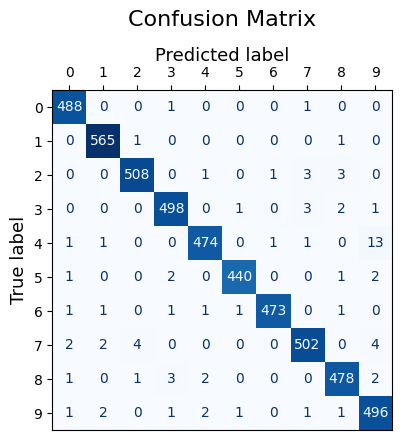

In [77]:
tree = scan_dir('model',          # directory to list
                tag='trained',    # file files with this tag
                sortbydate=True)  # sort by date

for i, f in enumerate(tree): print(f'[{i}]:', f)
    
# ask to the user which model to load:
rank = int(input('\nrank of the model to load? ') )

# Load the choosen model:
trained_file = tree[rank]
print(f'loading trained model from <{trained_file}>')
model = tf.keras.models.load_model(trained_file)

# evaluate the model with the test dataset: 
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'test_accuracy = {test_acc*100:.2f}%, test_loss = {test_loss:.2e}')

# Predicting labels for test images:
test_pred = model.predict(x_test, verbose=0)   # array of none-hot vectors
pred_lab  = np.argmax(test_pred, axis=-1)      # array of lavels (integers)

# Show the classification repport:
print("Classification Report:\n", classification_report(test_lab, pred_lab))

# Show confusion MAtrix:
show_conf_matrix(test_lab, pred_lab, class_label=range(NB_CLASS), figsize=(6,5))

# 7 - Cross-Validation of the model

<span style="color:maroon; font-family:arial; font-size:11pt;">
    Cross-Validation (CV) in deep learning aims to reliably estimate a model’s generalization performance and guide model selection or hyperparameter tuning by testing how well the model performs on data not used for training. 
</span>    

We use the [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) and 
[StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold) functions proposed by the **scikit learn** module:

In [78]:
from sklearn.model_selection import KFold, StratifiedKFold

`KFold`as well as `StratifiedKFold`provides **indices** which can be used to split the full dataset into train & valid  datasets.

## 7.2 `K-Fold` versus `Stratified K-Fold`

Let's look at the **proportion of the classes** in the train and valid datasets build with `KFold`:

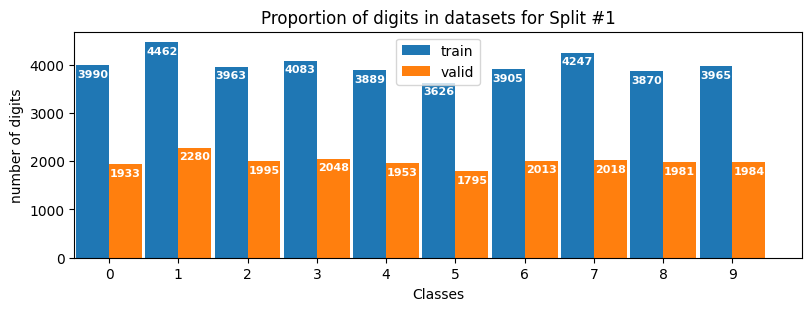

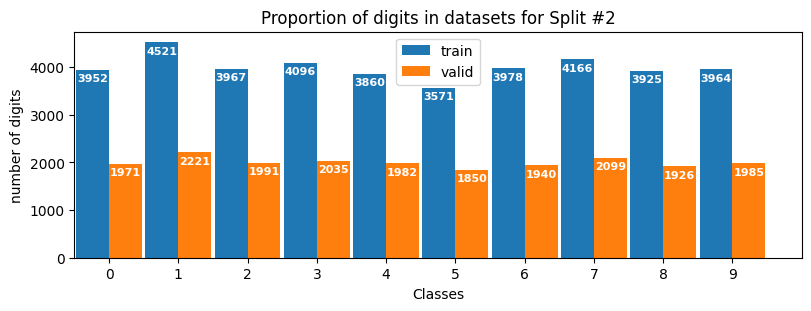

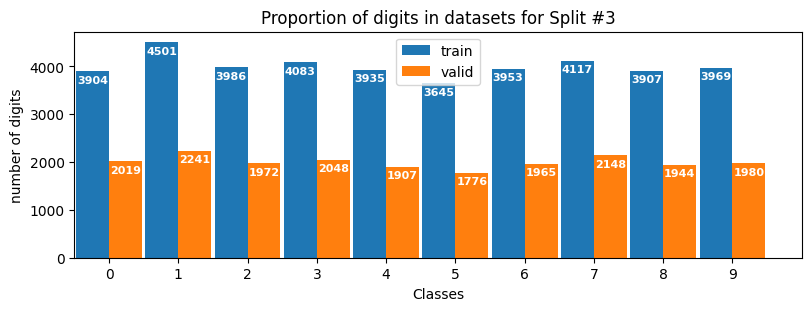

In [79]:
# Build a Kfold object with 3 folds:
kf = KFold(n_splits=3, shuffle=True, random_state=SEED)

# Explore the 3 splits of the datset available wit kf:
for s, (train_index, valid_index) in enumerate(kf.split(x_train)):

    # Build the train and valid datasets (images & labels) with the indices returned by kf:
    x_train_CV, y_train_CV = x_train[train_index], y_train[train_index]
    x_valid_CV, y_valid_CV = x_train[valid_index], y_train[valid_index]

    # build the dictionnary of number of classes per dataset:
    prop = {}
    prop['train'] = [ (np.argmax(y_train_CV, axis=-1) == i).sum() for i in range(10)]  # Comprehension list [# of 1, # of 2...] in the train dataset
    prop['valid'] = [ (np.argmax(y_valid_CV, axis=-1) == i).sum() for i in range(10)]  # Comprehension list [# of 1, # of 2...] in the valid dataset
    title =f'Proportion of digits in datasets for Split #{s + 1}'
    plot_proportion_bar(prop, range(NB_CLASS), title=title, figsize=(8,3))

<span style="color:maroon; font-family:arial; font-size:11pt;">
    $\leadsto$ The proportion of digits is quite homogeneous but varies among the 5 splits
</span>    

Now let's look at the proposrtion of the classes in the train and valid datasets build with `StratifiedKFold`:

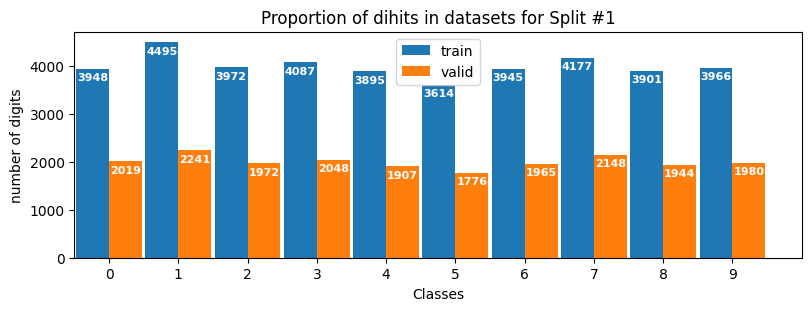

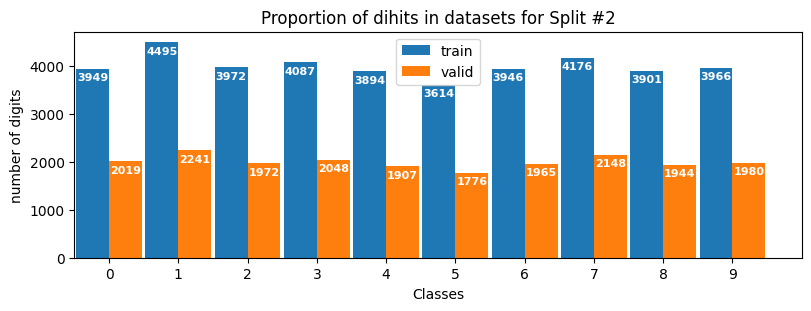

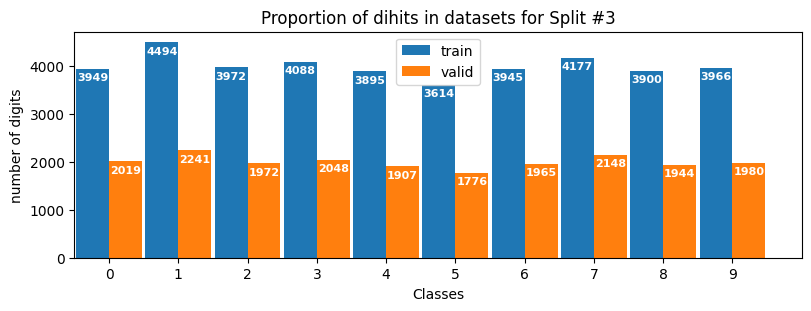

In [80]:
# Build a Kfold object with 3 folds:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Explore the 3 splits of the datset available wit kf:
for s, (train_index, vaild_index) in enumerate(skf.split(x_train, train_lab)):

    # Build the train and valid datasets (images & labels) with the indices returned by kf:
    x_train_CV, y_train_CV = x_train[train_index], y_train[train_index]
    x_valid_CV, y_valid_CV = x_train[valid_index], y_train[valid_index]

    # build the dictionnary of number of classes per dataset:
    prop = {}
    prop['train'] = [ (np.argmax(y_train_CV, axis=-1) == i).sum() for i in range(10)]  # Comprehension list [# of 1, # of 2...] in the train dataset
    prop['valid'] = [ (np.argmax(y_valid_CV, axis=-1) == i).sum() for i in range(10)]  # Comprehension list [# of 1, # of 2...] in the valid dataset
    title =f'Proportion of dihits in datasets for Split #{s + 1}'
    plot_proportion_bar(prop, range(NB_CLASS), title=title, figsize=(8,3))

<span style="color:maroon; font-family:arial; font-size:12pt;">
    $\leadsto$ With the <b>stratified K-Fold</b>, the proportion of digits is quite homogeneous and remain the same among the different splits
</span>    

## 7.2 Example of the Cross-validation of model

The cell below shoes a possible way to implement cross-validation with Strafied K-Fold: 

In [81]:
SEED       = 1234
DROPOUT    = 0.4

METRIC     = 'val_loss'
PATIENCE   = 2

NB_EPOCH   = 25
BATCH_SIZE = 32

NB_SPLIT   = 5     # Training dataset divided into 5 folds

skf = StratifiedKFold(n_splits=NB_SPLIT, shuffle=True, random_state=SEED)

# lists to store metrics at each loop lap:
VAL_ACC, VAL_LOSS = [], []

for s, (train_index, valid_index) in enumerate(skf.split(x_train, train_lab)):
    
    x_train_CV, y_train_CV = x_train[train_index], y_train[train_index]
    x_valid_CV, y_valid_CV = x_train[valid_index], y_train[valid_index]
    
    t0 = time()
    print(f'\nSplit #{s + 1}')

    #
    # 1 - define the list of 'callback' fucntions:
    #
    callbacks_list = [
        EarlyStopping(monitor=METRIC,     # The parameter to monitor
                      patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                      restore_best_weights=True,
                      verbose=1) ]
    model_name = f'DNN_seed-{SEED}_drop-{DROPOUT}'
    model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, dropout=DROPOUT, seed=SEED, name=model_name)

    #
    # 2 - Model training:
    #
    hist = model.fit(x_train_CV, y_train_CV,
                     validation_data=(x_valid_CV, y_valid_CV), 
                     epochs=NB_EPOCH,       # the total number of successive trainings
                     batch_size=BATCH_SIZE, # fragmentation of the whole dada set in batches
                     callbacks = callbacks_list,
                     verbose=3)
    elaps = elapsed_time_since(t0)
    print(elaps)  

    #
    # 3 - evaluate the model with the validation dataset: 
    #
    print('\nEvaluation of the model performance with the Validation fold:')
    val_loss, val_acc = model.evaluate(x_valid, y_valid, verbose=2)   
    VAL_ACC.append(val_acc)
    VAL_LOSS.append(val_loss)
    print()

# transform lists in ndarrays:    
VAL_ACC  = np.array(VAL_ACC)
VAL_LOSS = np.array(VAL_LOSS)

print(f'\n Validation accuracy & loss evaluated with {NB_SPLIT} folds:')
print(f'\t average accuracy: {VAL_ACC.mean():.3f}, std: {VAL_ACC.std():.4f}')  
print(f'\t average Loss    : {VAL_LOSS.mean():.3f}, std: {VAL_LOSS.std():.4f}')


Split #1
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 7/25
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
Elapsed time 40s -> 00:00:40

Evaluation of the model performance with the Validation fold:
157/157 - 0s - 2ms/step - accuracy: 0.9816 - loss: 0.0586


Split #2
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 7/25
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
Elapsed time 38s -> 00:00:38

Evaluation of the model performance with the Validation fold:
157/157 - 0s - 2ms/step - accuracy: 0.9788 - loss: 0.0669


Split #3
Epoch 1/25
Epoch 2/25
Epoch 3/25
Epoch 4/25
Epoch 5/25
Epoch 6/25
Epoch 7/25
Epoch 8/25
Epoch 9/25
Epoch 10/25
Epoch 11/25
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 9.
Elapsed time 60s -> 00:01:00

Evaluation of the model performance with the Validation fold:
157/157 - 0s - 2ms/step - accuracy: 0.9814 - loss

<span style="color:maroon; font-family:arial; font-size:11pt;">
    Average accuracy of 98% has a low std value: it is a significant performances of the trained model.<br>
</span>    

# Conclusion

<span style="color:maroon; font-family:arial; font-size:12pt;">

What you have learned in this notebook:
<ul>
  <li>How to run a reproducible trainning of a model with the tensorflow module</li>
  <li>What are the main metrics used to evaluate a classification model, and how can they be implemented with tensorflow?</li>
  <li>How to use the <b>earlyStopping</b> technique to avoid overfit while training the model </li>
  <li>How to implement the <b>dropout</b> regularization with TensorFlow</li>
  <li>How to use the Cross-Validation strategy to get a consistent evalauation of the performance of a trained model.</li>
</ul>

$\leadsto$ in the next notebook <i>03-Hyperparam_tunning.ipynb</i>, you will learn how to tune some of the hyperparameters which influence the training of a model.
</span>    